1. Why This Project

Learn temporal trend analysis.

Handle time-series style data.

Visualize long-term passenger growth and monthly seasonality.


2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


3. Load Dataset

In [2]:
df = sns.load_dataset('flights')
df.head()


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


4. Explore Data

In [3]:
print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())


Shape: (144, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB
None
year          0
month         0
passengers    0
dtype: int64
              year  passengers
count   144.000000  144.000000
mean   1954.500000  280.298611
std       3.464102  119.966317
min    1949.000000  104.000000
25%    1951.750000  180.000000
50%    1954.500000  265.500000
75%    1957.250000  360.500000
max    1960.000000  622.000000


Insights:

144 rows × 3 columns (year, month, passengers).

Monthly air passenger counts from 1949–1960.

No missing values.

5. Data Cleaning

In [4]:
# Convert year to int and month to categorical
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype('category')

# Ensure chronological order
df.sort_values(by=['year', 'month'], inplace=True)


6. Analysis with NumPy & Pandas

In [5]:
# Average passengers
avg_passengers = np.mean(df['passengers'])
print("Average Passengers:", avg_passengers)

# Yearly totals
yearly_total = df.groupby('year')['passengers'].sum()
print("Total Passengers by Year:\n", yearly_total)

# Monthly averages
monthly_avg = df.groupby('month')['passengers'].mean()
print("Average Passengers by Month:\n", monthly_avg)


Average Passengers: 280.2986111111111
Total Passengers by Year:
 year
1949    1520
1950    1676
1951    2042
1952    2364
1953    2700
1954    2867
1955    3408
1956    3939
1957    4421
1958    4572
1959    5140
1960    5714
Name: passengers, dtype: int64
Average Passengers by Month:
 month
Jan    241.750000
Feb    235.000000
Mar    270.166667
Apr    267.083333
May    271.833333
Jun    311.666667
Jul    351.333333
Aug    351.083333
Sep    302.416667
Oct    266.583333
Nov    232.833333
Dec    261.833333
Name: passengers, dtype: float64


C:\Users\Nandini Patel\AppData\Local\Temp\ipykernel_14624\3456266265.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = df.groupby('month')['passengers'].mean()


7. Visualization with Matplotlib

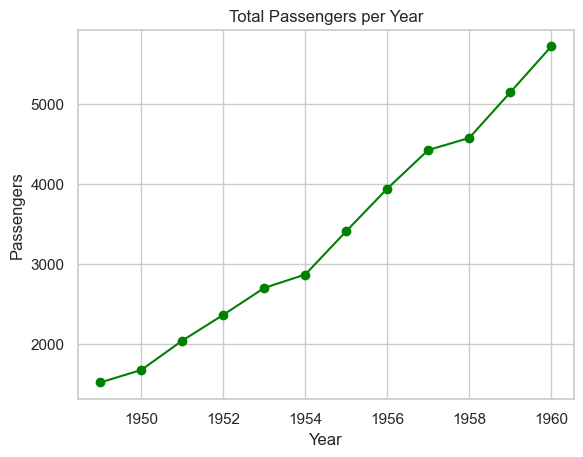

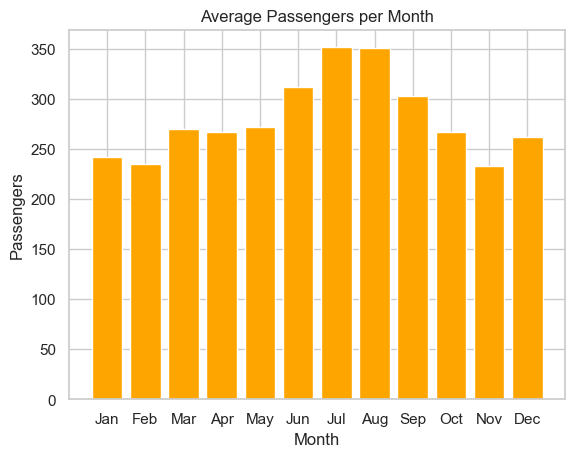

In [6]:
# Line plot (trend over years)
plt.plot(yearly_total.index, yearly_total.values, marker='o', color='green')
plt.title("Total Passengers per Year")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

# Bar chart (average by month)
plt.bar(monthly_avg.index, monthly_avg.values, color='orange')
plt.title("Average Passengers per Month")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.show()


# Insights:

Continuous upward trend—commercial flight growth era.

Seasonal spikes mid-year.

8. Visualization with Seaborn

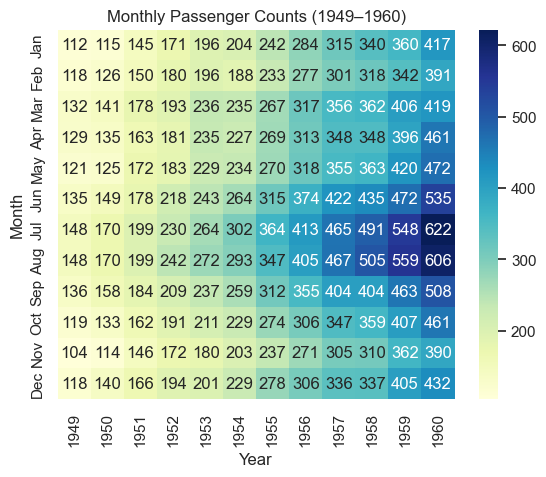

C:\Users\Nandini Patel\AppData\Local\Temp\ipykernel_14624\2151955726.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='year', y='passengers', data=df, ci=None, marker='o', color='green')


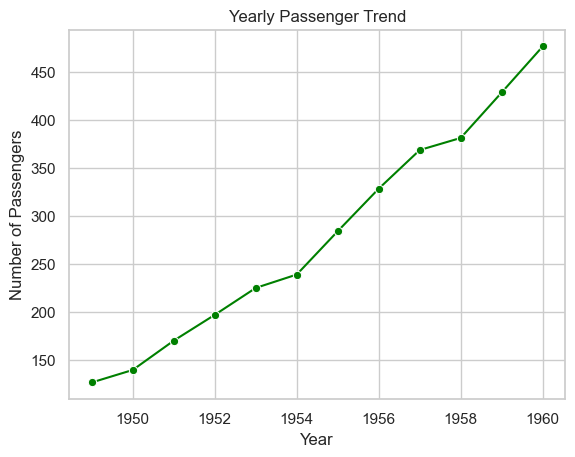

In [8]:
pivot = df.pivot(index='month', columns='year', values='passengers')
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Monthly Passenger Counts (1949–1960)")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

# Line plot for yearly trend
sns.lineplot(x='year', y='passengers', data=df, ci=None, marker='o', color='green')
plt.title("Yearly Passenger Trend")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.show()
